In [394]:
import pandas as pd
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [395]:
df=pd.read_csv('Churn_Modelling.csv')

In [396]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [397]:
le_geo = LabelEncoder()
le_gender = LabelEncoder()


In [398]:
df['Geography'] = le_geo.fit_transform(df['Geography'])
df['Gender'] = le_gender.fit_transform(df['Gender'])

pca = PCA(n_components=0.80)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [399]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [400]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [401]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [402]:
rf=RandomForestClassifier()
rf.fit(X_train,y_train)


RandomForestClassifier()

In [403]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=3, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("🔹 Best Parameters:", search.best_params_)

🔹 Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}


In [404]:
y_pred = best_model.predict(X_test)

In [405]:
print(" Accuracy:", accuracy_score(y_test, y_pred))
print(" Classification Report:\n", classification_report(y_test, y_pred))

 Accuracy: 0.8685
 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



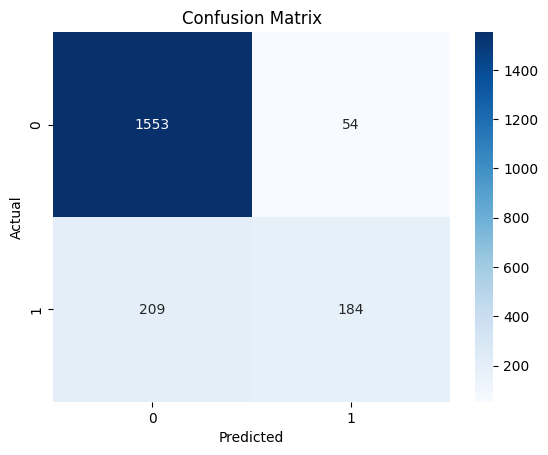

In [406]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()